# Stock Price Prediction using LSTM
## Training Model on RELIANCE.NS Stock

In [1]:
## Import Libraries
import numpy as np
import pandas as pd
import yfinance as yf
import pickle
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

import warnings
warnings.filterwarnings('ignore')

## Step 1: Download NIFTY 50 Stock Data (5 Years)

In [2]:
## NIFTY 50 Stock List
nifty50_stocks = [
    "RELIANCE.NS", "TCS.NS", "HDFCBANK.NS", "ICICIBANK.NS", "INFY.NS",
    "HINDUNILVR.NS", "ITC.NS", "SBIN.NS", "BHARTIARTL.NS", "KOTAKBANK.NS",
    "LT.NS", "AXISBANK.NS", "BAJFINANCE.NS", "ASIANPAINT.NS", "MARUTI.NS",
    "HCLTECH.NS", "SUNPHARMA.NS", "TITAN.NS", "ULTRACEMCO.NS", "NESTLEIND.NS",
    "WIPRO.NS", "ONGC.NS", "NTPC.NS", "POWERGRID.NS", "ADANIENT.NS",
    "ADANIPORTS.NS", "BAJAJFINSV.NS", "BAJAJ-AUTO.NS", "BRITANNIA.NS",
    "CIPLA.NS", "COALINDIA.NS", "DRREDDY.NS", "EICHERMOT.NS", "GRASIM.NS",
    "HEROMOTOCO.NS", "HINDALCO.NS", "INDUSINDBK.NS", "JSWSTEEL.NS",
    "M&M.NS", "SBILIFE.NS", "SHREECEM.NS", "TECHM.NS", "TATASTEEL.NS",
    "TATACONSUM.NS", "TATAMOTORS.NS", "UPL.NS", "DIVISLAB.NS", "APOLLOHOSP.NS",
    "BPCL.NS", "HDFCLIFE.NS"
]

print(f"Total stocks: {len(nifty50_stocks)}")

Total stocks: 50


In [3]:
## Download 5 years data for all NIFTY 50 stocks
import yfinance as yf
import pandas as pd
import os

os.makedirs("data", exist_ok=True)

for stock in nifty50_stocks:
    try:
        print(f"Downloading {stock}...")
        data = yf.download(stock, period="5y")
        
        if not data.empty:
            filename = f"data/{stock.replace('.NS', '')}.csv"
            data.to_csv(filename)
            print(f"✓ Saved {filename} - Shape: {data.shape}")
        else:
            print(f"✗ No data for {stock}")
    except Exception as e:
        print(f"✗ Error downloading {stock}: {e}")

print("\n✓ Data download completed!")

[*********************100%***********************]  1 of 1 completed


✓ Saved data/RELIANCE.csv - Shape: (1236, 5)


[*********************100%***********************]  1 of 1 completed


✓ Saved data/TCS.csv - Shape: (1236, 5)


[*********************100%***********************]  1 of 1 completed


...

✓ Saved data/APOLLOHOSP.csv - Shape: (1236, 5)


[*********************100%***********************]  1 of 1 completed


✓ Saved data/BPCL.csv - Shape: (1236, 5)


[*********************100%***********************]  1 of 1 completed

✓ Saved data/HDFCLIFE.csv - Shape: (1236, 5)

✓ Data download completed!


## Step 2: Load and Explore RELIANCE Stock Data (Training Stock)

In [4]:
## Load RELIANCE data for training
df = pd.read_csv('data/RELIANCE.csv', index_col=0, parse_dates=True)

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
print(df.describe())

Dataset Shape: (1238, 5)

First 5 rows:
                        Close                High                Low  \
Price                                                                  
Ticker            RELIANCE.NS         RELIANCE.NS        RELIANCE.NS   
Date                      NaN                 NaN                NaN   
2021-03-10     989.3642578125  1004.3955499162571  984.0591241137868   
2021-03-12  969.2546997070312  1000.4507422731192  963.0426687169551   
2021-03-15     956.2412109375   974.3784296324053  943.3637304935054   

                          Open       Volume  
Price                                        
Ticker             RELIANCE.NS  RELIANCE.NS  
Date                       NaN          NaN  
2021-03-10  1000.7227465962088     11519358  
2021-03-12   995.2816157511662     16864952  
2021-03-15   970.3656071763525     16698099  

Dataset Info:
<class 'pandas.DataFrame'>
Index: 1238 entries, Ticker to 2026-03-10
Data columns (total 5 columns):
 #   Column  Non-

In [6]:
print(df.head())
print(df.dtypes)

                        Close                High                Low  \
Price                                                                  
Ticker            RELIANCE.NS         RELIANCE.NS        RELIANCE.NS   
Date                      NaN                 NaN                NaN   
2021-03-10     989.3642578125  1004.3955499162571  984.0591241137868   
2021-03-12  969.2546997070312  1000.4507422731192  963.0426687169551   
2021-03-15     956.2412109375   974.3784296324053  943.3637304935054   

                          Open       Volume  
Price                                        
Ticker             RELIANCE.NS  RELIANCE.NS  
Date                       NaN          NaN  
2021-03-10  1000.7227465962088     11519358  
2021-03-12   995.2816157511662     16864952  
2021-03-15   970.3656071763525     16698099  
Close     str
High      str
Low       str
Open      str
Volume    str
dtype: object


In [7]:
df['Close'] = pd.to_numeric(df['Close'], errors='coerce')

In [8]:
df = df.dropna(subset=['Close'])

In [10]:
df.index

Index(['2021-03-10', '2021-03-12', '2021-03-15', '2021-03-16', '2021-03-17',
       '2021-03-18', '2021-03-19', '2021-03-22', '2021-03-23', '2021-03-24',
       ...
       '2026-02-24', '2026-02-25', '2026-02-26', '2026-02-27', '2026-03-02',
       '2026-03-04', '2026-03-05', '2026-03-06', '2026-03-09', '2026-03-10'],
      dtype='str', name='Price', length=1236)

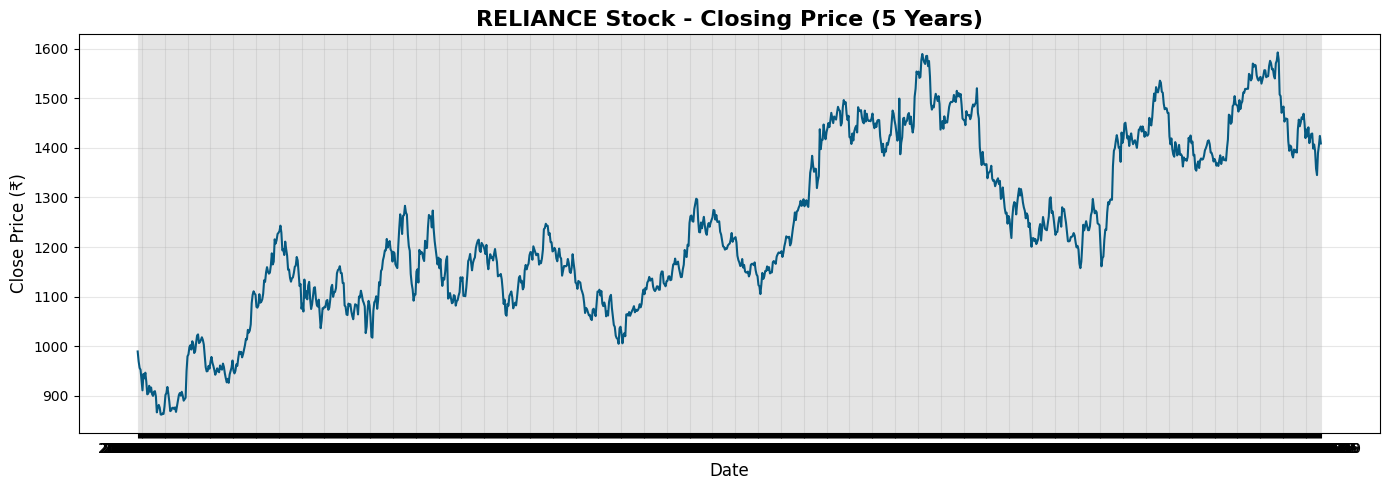

In [11]:
## Visualize Closing Price
plt.figure(figsize=(14, 5))
plt.plot(df.index, df['Close'], color='#065A82', linewidth=1.5)
plt.title('RELIANCE Stock - Closing Price (5 Years)', fontsize=16, weight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Close Price (₹)', fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Step 3: Feature Selection - Using Close Price Only

In [12]:
## Select Close price for prediction
data = df[['Close']].values

print(f"Data shape: {data.shape}")
print(f"Total days: {len(data)}")

Data shape: (1236, 1)
Total days: 1236


## Step 4: Data Scaling (MinMaxScaler)

In [13]:
## Scaling data to range [0, 1]
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

print(f"Original data range: {data.min():.2f} to {data.max():.2f}")
print(f"Scaled data range: {scaled_data.min():.2f} to {scaled_data.max():.2f}")

## Save scaler for future predictions
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
    
print("\n✓ Scaler saved as 'scaler.pkl'")

Original data range: 862.04 to 1592.30
Scaled data range: 0.00 to 1.00

✓ Scaler saved as 'scaler.pkl'


## Step 5: Create Sequences for LSTM (60 days lookback)

In [14]:
## Create sequences: Use past 60 days to predict next day
sequence_length = 60

X = []
y = []

for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i, 0])  # Past 60 days
    y.append(scaled_data[i, 0])  # Next day price

X = np.array(X)
y = np.array(y)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (1176, 60)
y shape: (1176,)


## Step 6: Train-Test Split (80-20)

In [15]:
## Split: 80% training, 20% testing
split = int(0.8 * len(X))

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 940
Testing samples: 236


In [16]:
## Reshape for LSTM: (samples, time_steps, features)
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (940, 60, 1)
X_test shape: (236, 60, 1)


## Step 7: Build LSTM Model

In [17]:
## LSTM Model Architecture
model = Sequential()

# First LSTM layer with Dropout
model.add(LSTM(units=64, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))

# Second LSTM layer with Dropout
model.add(LSTM(units=64, return_sequences=False))
model.add(Dropout(0.2))

# Dense layers
model.add(Dense(units=25, activation='relu'))
model.add(Dense(units=1))  ## Output layer

# Compile model
model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mae']
)

print("✓ Model Built Successfully!")
model.summary()

✓ Model Built Successfully!


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,625 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,571 (201.45 KB)

 Trainable params: 51,571 (201.45 KB)

 Non-trainable params: 0 (0.00 B)

## Step 8: Train Model with Callbacks

In [18]:
## Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'stock_lstm_model.h5',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

## Train model
print("\n🚀 Starting Training...\n")

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, checkpoint],
    verbose=1
)

print("\n✓ Training Complete!")


🚀 Starting Training...

Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - loss: 0.0790 - mae: 0.2101
Epoch 1: val_loss improved from None to 0.01323, saving model to stock_lstm_model.h5



Epoch 1: finished saving model to stock_lstm_model.h5
30/30 ━━━━━━━━━━━━━━━━━━━━ 17s 153ms/step - loss: 0.0352 - mae: 0.1302 - val_loss: 0.0132 - val_mae: 0.0998
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 0.0070 - mae: 0.0636
Epoch 2: val_loss improved from 0.01323 to 0.00449, saving model to stock_lstm_model.h5



Epoch 2: finished saving model to stock_lstm_model.h5
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 104ms/step - loss: 0.0066 - mae: 0.0628 - val_loss: 0.0045 - val_mae: 0.0537
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - loss: 0.0049 - mae: 0.0533
Epoch 3: val_loss improved from 0.00449 to 0.00395, saving model to stock_lstm_model.h5



Epoch 3: finished saving model to stock_lstm_model.h5
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 99ms/step - loss: 0.0052 - mae: 0.0553 - val_loss: 0.0039 - val_mae: 0.0487
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 0.0044 - mae: 0.0517
Epoch 4: val_loss did not improve from 0.00395
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 98ms/step - loss: 0.0045 - mae: 0.0519 - val_loss: 0.0049 - val_mae: 0.0565
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 0.0050 - mae: 0.0548
Epoch 5: val_loss improved from 0.00395 to 0.00341, saving model to stock_lstm_model.h5



Epoch 5: finished saving model to stock_lstm_model.h5
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 102ms/step - loss: 0.0052 - mae: 0.0555 - val_loss: 0.0034 - val_mae: 0.0447
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 0.0054 - mae: 0.0561
Epoch 6: val_loss improved from 0.00341 to 0.00333, saving model to stock_lstm_model.h5


...


Epoch 28: finished saving model to stock_lstm_model.h5
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 105ms/step - loss: 0.0023 - mae: 0.0366 - val_loss: 0.0015 - val_mae: 0.0299
Epoch 29/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 0.0022 - mae: 0.0354
Epoch 29: val_loss did not improve from 0.00153
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 92ms/step - loss: 0.0021 - mae: 0.0351 - val_loss: 0.0039 - val_mae: 0.0546
Epoch 30/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 0.0019 - mae: 0.0339
Epoch 30: val_loss did not improve from 0.00153
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - loss: 0.0020 - mae: 0.0340 - val_loss: 0.0027 - val_mae: 0.0443
Epoch 31/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 0.0021 - mae: 0.0360
Epoch 31: val_loss improved from 0.00153 to 0.00151, saving model to stock_lstm_model.h5



Epoch 31: finished saving model to stock_lstm_model.h5
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 92ms/step - loss: 0.0020 - mae: 0.0348 - val_loss: 0.0015 - val_mae: 0.0304
Epoch 32/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 0.0019 - mae: 0.0341
Epoch 32: val_loss did not improve from 0.00151
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - loss: 0.0019 - mae: 0.0343 - val_loss: 0.0021 - val_mae: 0.0381
Epoch 33/50
29/30 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 0.0020 - mae: 0.0345
Epoch 33: val_loss did not improve from 0.00151
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step - loss: 0.0019 - mae: 0.0338 - val_loss: 0.0020 - val_mae: 0.0372
Epoch 34/50
29/30 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.0020 - mae: 0.0338
Epoch 34: val_loss did not improve from 0.00151
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - loss: 0.0018 - mae: 0.0323 - val_loss: 0.0016 - val_mae: 0.0323
Epoch 35/50
29/30 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 0.0015 - mae: 0.0298
Epoch 35: val_loss did not improve from 0.00151
30/3


Epoch 36: finished saving model to stock_lstm_model.h5
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - loss: 0.0018 - mae: 0.0323 - val_loss: 0.0013 - val_mae: 0.0274
Epoch 37/50
29/30 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 0.0018 - mae: 0.0333
Epoch 37: val_loss did not improve from 0.00127
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - loss: 0.0017 - mae: 0.0326 - val_loss: 0.0013 - val_mae: 0.0269
Epoch 38/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 0.0016 - mae: 0.0312
Epoch 38: val_loss did not improve from 0.00127
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - loss: 0.0016 - mae: 0.0313 - val_loss: 0.0019 - val_mae: 0.0354
Epoch 39/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 0.0016 - mae: 0.0315
Epoch 39: val_loss did not improve from 0.00127
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - loss: 0.0017 - mae: 0.0321 - val_loss: 0.0042 - val_mae: 0.0576
Epoch 40/50
29/30 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 0.0019 - mae: 0.0346
Epoch 40: val_loss improved from 0.00127 to 0.00124,


Epoch 40: finished saving model to stock_lstm_model.h5
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - loss: 0.0018 - mae: 0.0331 - val_loss: 0.0012 - val_mae: 0.0265
Epoch 41/50
29/30 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 0.0015 - mae: 0.0304
Epoch 41: val_loss did not improve from 0.00124
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - loss: 0.0016 - mae: 0.0312 - val_loss: 0.0014 - val_mae: 0.0280
Epoch 42/50
29/30 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 0.0017 - mae: 0.0308
Epoch 42: val_loss did not improve from 0.00124
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - loss: 0.0017 - mae: 0.0311 - val_loss: 0.0020 - val_mae: 0.0374
Epoch 43/50
29/30 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 0.0017 - mae: 0.0319
Epoch 43: val_loss did not improve from 0.00124
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - loss: 0.0018 - mae: 0.0329 - val_loss: 0.0015 - val_mae: 0.0297
Epoch 44/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 0.0017 - mae: 0.0320
Epoch 44: val_loss did not improve from 0.00124
30/3


Epoch 47: finished saving model to stock_lstm_model.h5
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - loss: 0.0016 - mae: 0.0303 - val_loss: 0.0011 - val_mae: 0.0247
Epoch 48/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 0.0016 - mae: 0.0309
Epoch 48: val_loss did not improve from 0.00110
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - loss: 0.0015 - mae: 0.0297 - val_loss: 0.0012 - val_mae: 0.0259
Epoch 49/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 0.0014 - mae: 0.0292
Epoch 49: val_loss did not improve from 0.00110
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - loss: 0.0015 - mae: 0.0299 - val_loss: 0.0012 - val_mae: 0.0255
Epoch 50/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 0.0015 - mae: 0.0302
Epoch 50: val_loss did not improve from 0.00110
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - loss: 0.0015 - mae: 0.0297 - val_loss: 0.0013 - val_mae: 0.0280
Restoring model weights from the end of the best epoch: 47.

✓ Training Complete!


## Step 9: Visualize Training History

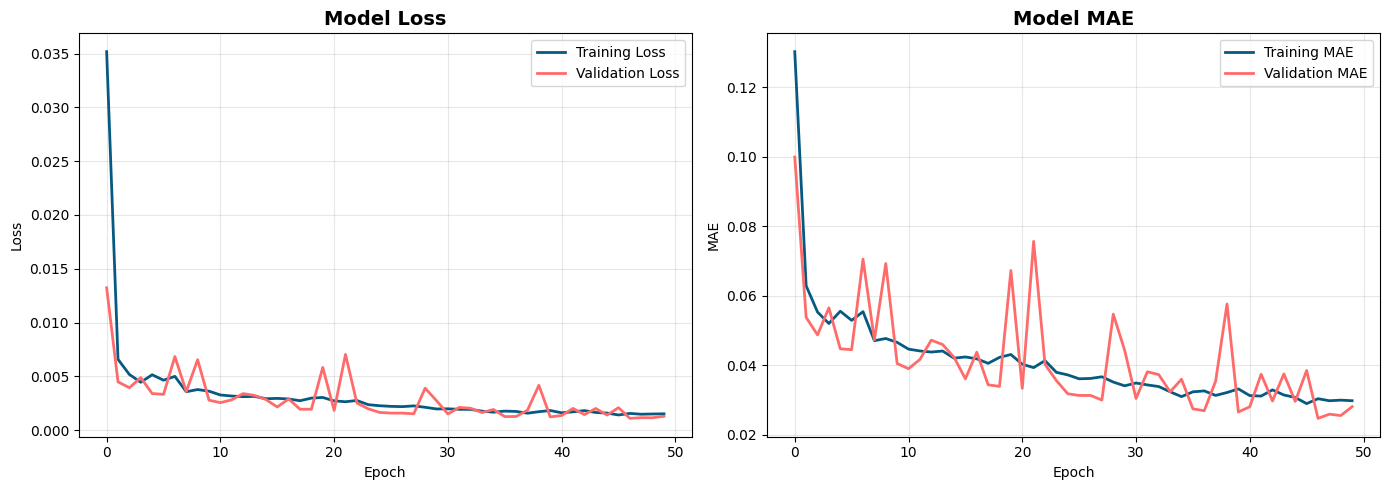

In [19]:
## Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axes[0].plot(history.history['loss'], label='Training Loss', color='#065A82', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss', color='#FF6B6B', linewidth=2)
axes[0].set_title('Model Loss', fontsize=14, weight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# MAE plot
axes[1].plot(history.history['mae'], label='Training MAE', color='#065A82', linewidth=2)
axes[1].plot(history.history['val_mae'], label='Validation MAE', color='#FF6B6B', linewidth=2)
axes[1].set_title('Model MAE', fontsize=14, weight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Step 10: Save Model

In [20]:
## Save final model
model.save("stock_lstm_model.h5")
print("✓ Model saved as 'stock_lstm_model.h5'")

print("\n" + "="*60)
print("✓ TRAINING COMPLETED SUCCESSFULLY!")
print("="*60)
print("\nFiles Created:")
print("  1. stock_lstm_model.h5 - Trained LSTM model")
print("  2. scaler.pkl - MinMaxScaler for preprocessing")
print("  3. data/ - Folder with all NIFTY 50 stock CSVs")
print("\nNext Step: Run 'prediction.ipynb' for testing and evaluation")
print("="*60)

✓ Model saved as 'stock_lstm_model.h5'

✓ TRAINING COMPLETED SUCCESSFULLY!

Files Created:
  1. stock_lstm_model.h5 - Trained LSTM model
  2. scaler.pkl - MinMaxScaler for preprocessing
  3. data/ - Folder with all NIFTY 50 stock CSVs

Next Step: Run 'prediction.ipynb' for testing and evaluation
